In [1]:
import os
os.chdir('/home/jovyan/signal-extraction') # set the current working directory to the base signal-extraction folder so vae and sim files and easily be called.

In [2]:
from vae_code.chat_gam_gnll_VAE import *

# Implementing the MIMO-AE

### Loading the reanalysis data

In [3]:
import xarray as xr

In [4]:
sdata1 = xr.open_dataset("./vae_input_data/sst_mon-mean.nc")
pdata1 = xr.open_dataset("./vae_input_data/tp_mon-sum.nc")

In [4]:
print(f"{pdata1}, /n {sdata1}")

<xarray.Dataset> Size: 1MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 17, longitude: 17)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 136B 40.0 39.75 39.5 ... 36.5 36.25 36.0
  * longitude        (longitude) float64 136B -123.0 -122.8 ... -119.2 -119.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    tp               (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 18:32:56 2025: CDO monsum ../signal-e...
    frequency:               mon
    CDO:         

### Running the VAE

In [53]:
m1 = learn(sdata1,pdata1,"minmax",'sst','tp', 1, 3, 0.8, 32)

Epoch 1/100 | Total: -0.6178 | SST (GNLL): -0.2689 | Precip (Gamma NLL): -0.4923 | KL: 0.1434
Epoch 2/100 | Total: -1.5389 | SST (GNLL): -0.6008 | Precip (Gamma NLL): -0.9694 | KL: 0.0313
Epoch 3/100 | Total: -2.2012 | SST (GNLL): -0.9910 | Precip (Gamma NLL): -1.2163 | KL: 0.0060
Epoch 4/100 | Total: -2.2161 | SST (GNLL): -0.9973 | Precip (Gamma NLL): -1.2220 | KL: 0.0032
Epoch 5/100 | Total: -2.2255 | SST (GNLL): -1.0040 | Precip (Gamma NLL): -1.2241 | KL: 0.0026
Epoch 6/100 | Total: -2.2107 | SST (GNLL): -1.0111 | Precip (Gamma NLL): -1.2021 | KL: 0.0024
Epoch 7/100 | Total: -2.2225 | SST (GNLL): -1.0294 | Precip (Gamma NLL): -1.1952 | KL: 0.0021
Epoch 8/100 | Total: -2.2453 | SST (GNLL): -1.0418 | Precip (Gamma NLL): -1.2054 | KL: 0.0020
Epoch 9/100 | Total: -2.2786 | SST (GNLL): -1.0592 | Precip (Gamma NLL): -1.2213 | KL: 0.0019
Epoch 10/100 | Total: -2.2159 | SST (GNLL): -1.0317 | Precip (Gamma NLL): -1.1860 | KL: 0.0018
Epoch 11/100 | Total: -2.2453 | SST (GNLL): -1.0331 | Preci

In [54]:
train_summary(m1,'./results/gam_gnll/chat_gam_VAE_s1r3_training_summary')

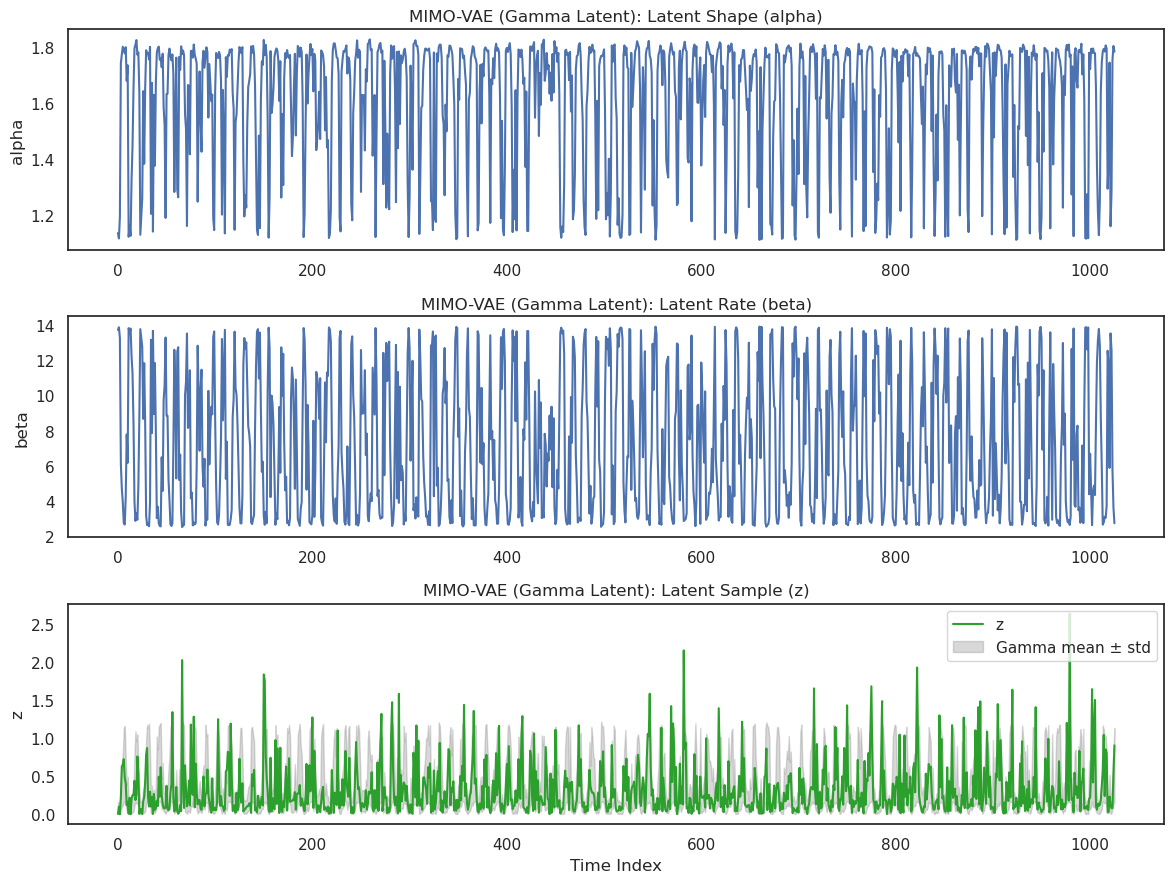

In [55]:
e1 = extractr(m1['model'],sdata1,'sst',pdata1,'tp',m1['sst_scaler'],m1['precip_scaler'],True,True,"./results/gam_gnll/gam_gnlls1r3_extractr_results")

In [56]:
from vae_code.plotter import *

In [57]:
gam_gnll_latent = pd.read_csv('~/signal-extraction/results/gam_gnll/gam_gnlls1r3_extractr_results_latent_full.csv')

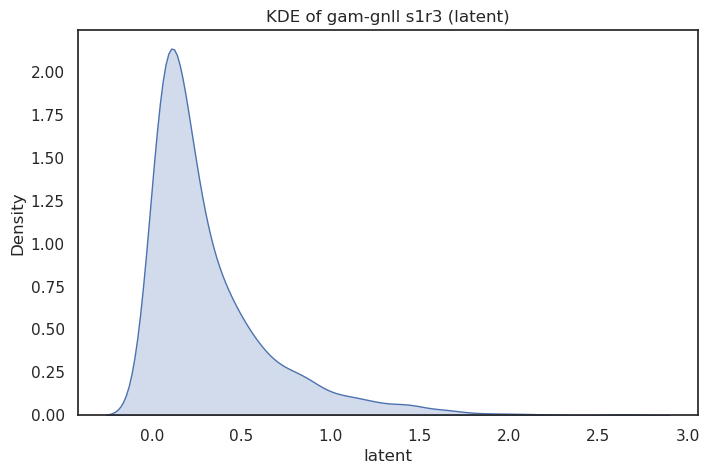

In [58]:
universalKDE('latent', 'gam-gnll s1r3',gam_gnll_latent['latent'])

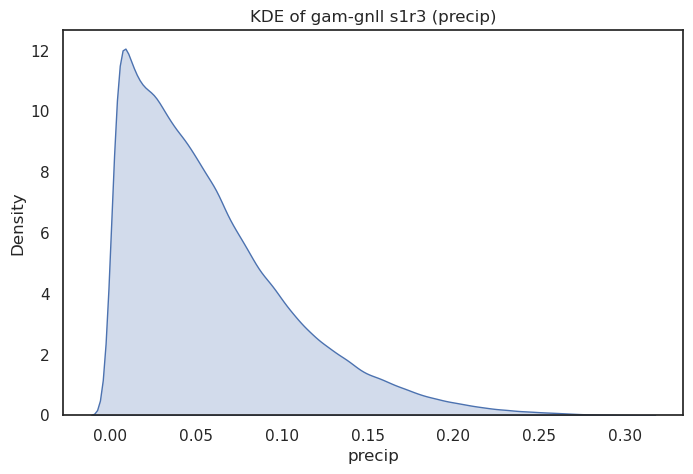

In [59]:
recon_pr = xr.open_dataset('~/signal-extraction/results/gam_gnll/gam_gnlls1r3_extractr_results_precip.nc')

universalKDE('precip', 'gam-gnll s1r3',recon_pr['precip'])

In [60]:
from simulator_code.Wavelet import *

In [61]:
# Load
signal = gam_gnll_latent

# --- Choose which latent variable to process ---
latent_var = 'latent'   # or "lambda", "alpha", "beta", etc.
time_var = 'time'

# Ensure datetime index (and sorted)
signal[time_var] = pd.to_datetime(signal[time_var], errors='coerce')
signal = signal.set_index(time_var).sort_index()

# Make sure latent_var column is numeric
signal[latent_var] = pd.to_numeric(signal[latent_var], errors='coerce')

# --- Shift to ensure positivity ---
latent_min = signal[latent_var].min()
if latent_min <= 0:
    eps = 1e-6  # nominal epsilon for numerical stability
    shift_value = -latent_min + eps
    signal[latent_var] = signal[latent_var] + shift_value
    print(f"Shifted '{latent_var}' upward by {shift_value:.6f} to ensure positivity.")

# Signal date window
sig_start = signal.index.min()
sig_end   = signal.index.max()

# Annual means of the latent variable
latent_annual_max = signal[latent_var].resample('YE').mean()

# Years (from the index, not the values)
latent_years = signal.index.year
latent_time = np.unique(latent_years)

# Series of annual mean values
latent_time_series = latent_annual_max.values


In [62]:
siglvl_wave = 0.95
sigtest = 'default'

In [63]:
# wavelet transform
#warnings.filterwarnings('ignore', 'divide by zero encountered in divide', RuntimeWarning)
wlt = wavelet(latent_time_series)
Cw = CI(wlt, latent_time_series, siglvl_wave, "r")
C = CI(wlt, latent_time_series, siglvl_wave, "w")

# Global Wavelet Spectrum
plt_dataset = {
    'Time': latent_time,
    'Period': wlt['period'],
    'Avg_Power': wlt['avg_power'],
    'Power': wlt['power'],
    'COI': wlt['coi'],
    'W_noise': C['sig'],
    'R_noise': Cw['sig']
}

Red Noise AR1 Coefficient: 0.9127106120261614


/home/jovyan/signal-extraction/simulator_code/Wavelet.py:50: RuntimeWarning: divide by zero encountered in divide
  expnt = -(scl * k - param) ** 2 / (2 * (k > 0))


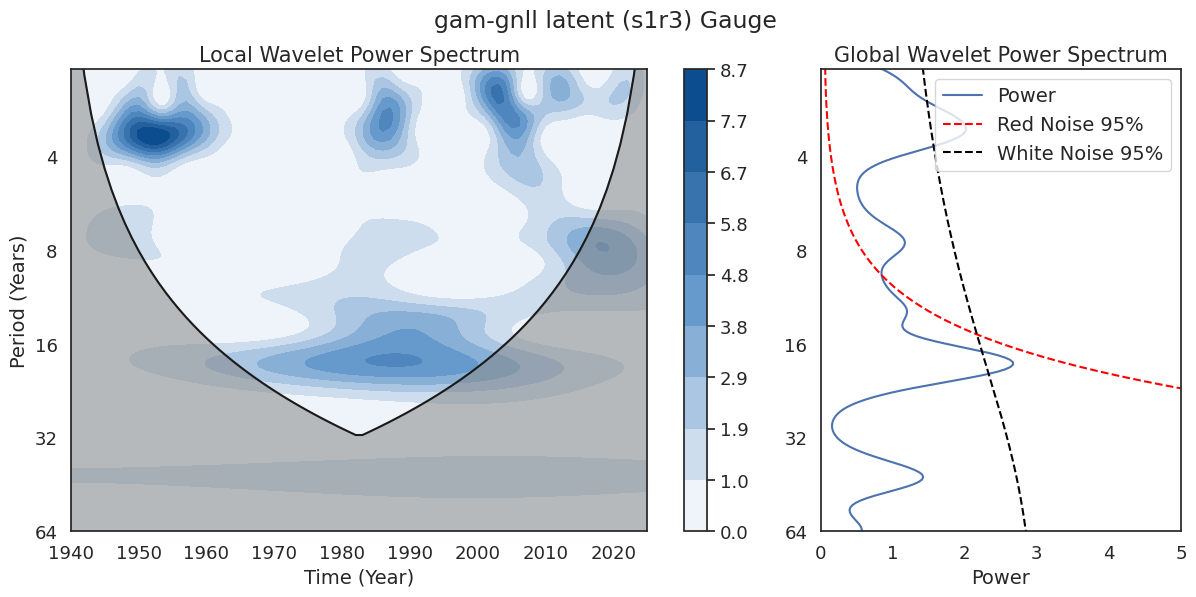

In [64]:
wavelet_plot(plt_dataset, siglvl_wave, 'gam-gnll latent (s1r3)', sigtest)